# Data Enrichment EDA — Authors, Citations, Venues, Notes

Descriptive EDA on `data/processed/papers_combined.parquet`. Read-only.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

DATA_PATH = Path("../../data/processed/papers_combined.parquet")

# Same palette as explore_use_cases.ipynb / explore_usecase_definitions.ipynb, so the
# label/use-case color language stays identical across every EDA notebook in the repo.
LABEL_COLORS = {"positive": "#2ca02c", "negative": "#d62728", "pass": "#9467bd"}
UNLABELLED_COLOR = "#c7c7c7"
USE_CASE_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e87ba4", "#eb6834"]
USE_CASE_SYMBOLS = ["circle", "square", "diamond", "cross", "triangle-up", "star"]

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH)
USE_CASE_ORDER = sorted(df["use_case_key"].unique())
USE_CASE_COLOR_MAP = dict(zip(USE_CASE_ORDER, USE_CASE_COLORS))
USE_CASE_SYMBOL_MAP = dict(zip(USE_CASE_ORDER, USE_CASE_SYMBOLS))
LABEL_ORDER = ["positive", "negative", "pass"]  # NaN ("never triaged") handled separately

print(f"Loaded {len(df)} rows x {len(df.columns)} columns from {DATA_PATH.name}")
print(f"Use cases ({len(USE_CASE_ORDER)}): {USE_CASE_ORDER}")
print(f"triage_label counts:\n{df['triage_label'].value_counts(dropna=False)}")

Loaded 2873 rows x 50 columns from papers_combined.parquet
Use cases (6): ['carbon_capture', 'cement_binders', 'ner', 'soil_microbiome', 'solar_leo', 'tech_forecasting']
triage_label counts:
triage_label
positive    1067
negative     785
pass         543
NaN          478
Name: count, dtype: int64


## 1. `notes` by use case

In [2]:
notes_by_uc = (
    df.drop_duplicates("use_case_key")[["use_case_key", "use_case_name", "notes"]]
    .assign(has_notes=lambda d: d["notes"].str.strip().str.len() > 0,
            word_count=lambda d: d["notes"].str.split().str.len().fillna(0).astype(int))
    .sort_values("use_case_key")
    .reset_index(drop=True)
)
print(f"{notes_by_uc['has_notes'].sum()} / {len(notes_by_uc)} use cases have a non-empty notes field.\n")
for _, row in notes_by_uc.iterrows():
    preview = row["notes"][:160] + ("..." if len(row["notes"]) > 160 else "") if row["has_notes"] else "(empty)"
    print(f"[{row['use_case_key']}] ({row['word_count']} words): {preview}\n")

4 / 6 use cases have a non-empty notes field.

[carbon_capture] (0 words): (empty)

[cement_binders] (8 words): Prioritise bigger impact potential over readiness and maturity

[ner] (0 words): (empty)

[soil_microbiome] (39 words): Scope covers the full range of farm sizes, from individual gardens to large commercial farms. Both microbial and fungal communities are of interest. Key outcome...

[solar_leo] (64 words): The analyst's own words for this area: “solar cells for low earth orbit satellites”.

Seeded from the reference lists of this field's review papers, so the star...

[tech_forecasting] (32 words): The graph is heterogeneous and decorated with varied content: TRL, costs, regulations, papers, citations. Methods should handle typed edges and mixed node/edge ...



## 2. Author count

In [3]:
def count_authors(s):
    if pd.isna(s) or s.strip() == "":
        return pd.NA
    return len([a for a in s.split(",") if a.strip()])

df["author_count"] = df["authors"].apply(count_authors).astype("Int64")

n_missing = df["author_count"].isna().sum()
print(f"author_count: {n_missing} / {len(df)} rows missing ({n_missing / len(df):.1%}) "
      f"— excluded from the stats below, not treated as 0.")
print(df["author_count"].describe())

author_count: 68 / 2873 rows missing (2.4%) — excluded from the stats below, not treated as 0.
count      2805.0
mean     5.281996
std      4.625101
min           1.0
25%           3.0
50%           4.0
75%           6.0
max          89.0
Name: author_count, dtype: Float64


In [4]:
authors_by_uc = (
    df.groupby("use_case_key")["author_count"]
    .agg(n_papers="count", mean="mean", median="median", min="min", max="max")
    .round(2)
    .reindex(USE_CASE_ORDER)
)
print("Author count by use case:")
authors_by_uc

Author count by use case:


,n_papers,mean,median,min,max
use_case_key,,,,,
carbon_capture,317,5.76,5.0,1,53
cement_binders,669,4.67,4.0,1,32
ner,533,4.02,3.0,1,34
soil_microbiome,587,5.68,5.0,1,89
solar_leo,411,7.58,5.0,1,64
tech_forecasting,288,4.42,4.0,1,21


In [5]:
authors_by_label = (
    df.groupby("triage_label", observed=True)["author_count"]
    .agg(n_papers="count", mean="mean", median="median", min="min", max="max")
    .round(2)
    .reindex(LABEL_ORDER)
)
print("Author count by triage_label (rows never triaged are excluded — see intro):")
authors_by_label

Author count by triage_label (rows never triaged are excluded — see intro):


,n_papers,mean,median,min,max
triage_label,,,,,
positive,1053,5.79,4.0,1,64
negative,774,5.33,4.0,1,53
pass,506,4.66,4.0,1,89


In [6]:
authors_by_uc_label = (
    df.groupby(["use_case_key", "triage_label"], observed=True)["author_count"]
    .agg(n="count", mean="mean", median="median")
    .round(2)
    .reset_index()
    .sort_values(["use_case_key", "triage_label"])
)
print("Author count by use case AND triage_label:")
authors_by_uc_label

Author count by use case AND triage_label:


,use_case_key,triage_label,n,mean,median
0,carbon_capture,positive,145,5.26,5.0
1,carbon_capture,negative,149,6.2,5.0
2,carbon_capture,pass,23,6.04,6.0
3,cement_binders,positive,165,4.68,4.0
4,cement_binders,negative,90,5.19,4.0
5,cement_binders,pass,96,3.85,3.0
6,ner,positive,218,3.74,3.0
7,ner,negative,88,4.02,3.5
8,ner,pass,73,3.44,3.0
9,soil_microbiome,positive,93,5.65,5.0


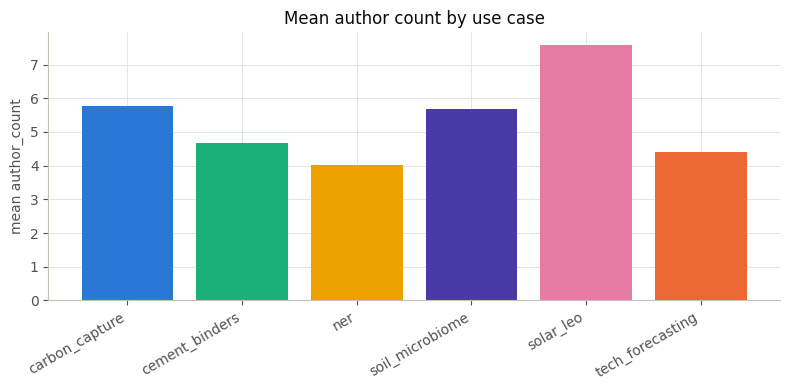

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
means = authors_by_uc["mean"]
ax.bar(means.index, means.values, color=[USE_CASE_COLOR_MAP[k] for k in means.index])
ax.set_ylabel("mean author_count")
ax.set_title("Mean author count by use case")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Citation count

In [8]:
n_missing = df["citation_count"].isna().sum()
print(f"citation_count: {n_missing} / {len(df)} rows null ({n_missing / len(df):.1%}), "
      f"excluded from mean/median below — never filled with 0.")
print(df["citation_count"].describe())

citation_count: 410 / 2873 rows null (14.3%), excluded from mean/median below — never filled with 0.
count       2463.0
mean     82.128705
std      578.97151
min            0.0
25%            0.0
50%            2.0
75%           41.0
max        26506.0
Name: citation_count, dtype: Float64


In [9]:
citations_by_uc = (
    df.groupby("use_case_key")["citation_count"]
    .agg(n_papers="count", mean="mean", median="median", max="max")
    .round(1)
    .reindex(USE_CASE_ORDER)
)
citations_by_uc["null_rate"] = (
    df.groupby("use_case_key")["citation_count"].apply(lambda s: s.isna().mean()).reindex(USE_CASE_ORDER).round(3)
)
print("Citation count by use case (n_papers = non-null count):")
citations_by_uc

Citation count by use case (n_papers = non-null count):


,n_papers,mean,median,max,null_rate
use_case_key,,,,,
carbon_capture,304,44.3,7.0,827,0.059
cement_binders,501,77.5,3.0,2310,0.274
ner,537,8.8,1.0,332,0.007
soil_microbiome,514,114.0,5.0,2089,0.146
solar_leo,387,222.1,7.0,26506,0.094
tech_forecasting,220,3.4,0.0,92,0.241


In [10]:
citations_by_label = (
    df.groupby("triage_label", observed=True)["citation_count"]
    .agg(n_papers="count", mean="mean", median="median", max="max")
    .round(1)
    .reindex(LABEL_ORDER)
)
print("Citation count by triage_label:")
citations_by_label

Citation count by triage_label:


,n_papers,mean,median,max
triage_label,,,,
positive,966,68.1,3.0,3670
negative,684,133.3,3.0,26506
pass,454,52.0,1.0,1985


In [11]:
citations_by_uc_label = (
    df.groupby(["use_case_key", "triage_label"], observed=True)["citation_count"]
    .agg(n="count", mean="mean", median="median")
    .round(1)
    .reset_index()
    .sort_values(["use_case_key", "triage_label"])
)
print("Citation count by use case AND triage_label:")
citations_by_uc_label

Citation count by use case AND triage_label:


,use_case_key,triage_label,n,mean,median
0,carbon_capture,positive,142,37.8,9.0
1,carbon_capture,negative,137,55.2,7.0
2,carbon_capture,pass,25,21.4,0.0
3,cement_binders,positive,161,67.9,18.0
4,cement_binders,negative,39,122.3,5.0
5,cement_binders,pass,96,34.3,0.0
6,ner,positive,221,6.3,1.0
7,ner,negative,88,11.1,1.0
8,ner,pass,74,6.9,0.0
9,soil_microbiome,positive,93,97.5,6.0


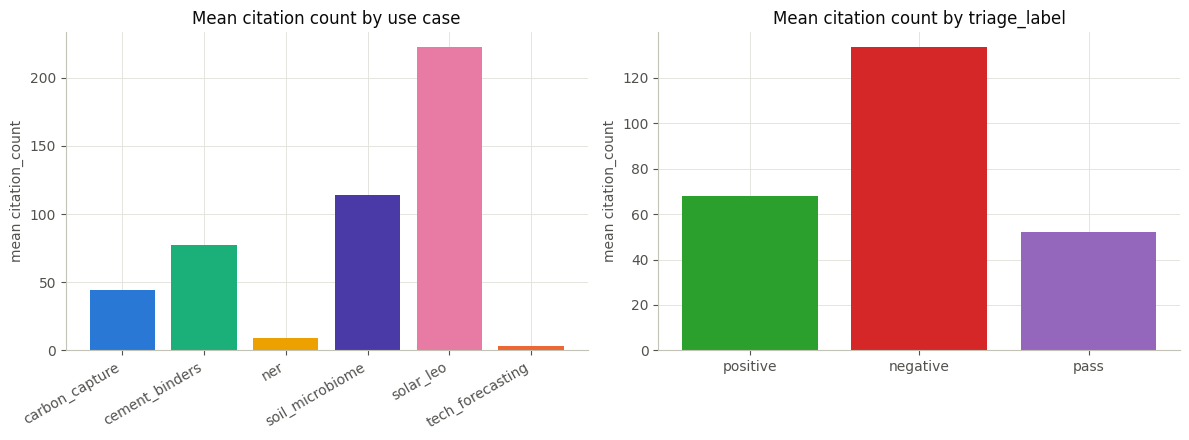

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

means = citations_by_uc["mean"]
axes[0].bar(means.index, means.values, color=[USE_CASE_COLOR_MAP[k] for k in means.index])
axes[0].set_ylabel("mean citation_count")
axes[0].set_title("Mean citation count by use case")
axes[0].tick_params(axis="x", rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

label_means = citations_by_label["mean"]
colors = [LABEL_COLORS[l] for l in label_means.index]
axes[1].bar(label_means.index, label_means.values, color=colors)
axes[1].set_ylabel("mean citation_count")
axes[1].set_title("Mean citation count by triage_label")

plt.tight_layout()
plt.show()

## 4. Most common venues

In [13]:
def has_venue(s):
    return s.notna() & (s.str.strip() != "")

overall_missing = 1 - has_venue(df["venue"]).mean()
print(f"venue: {overall_missing:.1%} of rows have no venue recorded (NaN or empty string), "
      f"excluded from every ranking below.\n")

top_venues_overall = (
    df.loc[has_venue(df["venue"]), "venue"].value_counts().head(10)
)
print("Top 10 venues overall:")
top_venues_overall

venue: 27.1% of rows have no venue recorded (NaN or empty string), excluded from every ranking below.

Top 10 venues overall:


venue
arxiv                                  96
scientific reports                     62
materials (basel, switzerland)         36
frontiers in microbiology              31
cement and concrete research           28
construction and building materials    28
nature communications                  26
ssrn electronic journal                21
arxiv (cornell university)             21
frontiers in plant science             20
Name: count, dtype: int64

In [14]:
def top_venue_row(s):
    known = s[has_venue(s)]
    n_total = len(s)
    if len(known) == 0:
        return pd.Series({"n_papers": n_total, "n_with_venue": 0, "venue_missing_rate": 1.0,
                           "top_venue": pd.NA, "top_venue_count": 0, "top_venue_share": np.nan})
    counts = known.value_counts()
    return pd.Series({
        "n_papers": n_total,
        "n_with_venue": len(known),
        "venue_missing_rate": round(1 - len(known) / n_total, 3),
        "top_venue": counts.index[0],
        "top_venue_count": counts.iloc[0],
        "top_venue_share": round(counts.iloc[0] / len(known), 3),
    })

venues_by_uc = (
    df.groupby("use_case_key")["venue"].apply(top_venue_row).unstack().reindex(USE_CASE_ORDER)
)
print("Most common venue by use case:")
venues_by_uc

Most common venue by use case:


,n_papers,n_with_venue,venue_missing_rate,top_venue,top_venue_count,top_venue_share
use_case_key,,,,,,
carbon_capture,323,203,0.372,ssrn electronic journal,15,0.074
cement_binders,690,523,0.242,arxiv,52,0.099
ner,541,430,0.205,arxiv (cornell university),17,0.04
soil_microbiome,602,446,0.259,frontiers in microbiology,31,0.07
solar_leo,427,302,0.293,perovskite solar cells,14,0.046
tech_forecasting,290,190,0.345,arxiv,16,0.084


In [15]:
venues_by_label = (
    df.groupby("triage_label", observed=True)["venue"].apply(top_venue_row).unstack().reindex(LABEL_ORDER)
)
print("Most common venue by triage_label:")
venues_by_label

Most common venue by triage_label:


,n_papers,n_with_venue,venue_missing_rate,top_venue,top_venue_count,top_venue_share
triage_label,,,,,,
positive,1067,759,0.289,arxiv,28,0.037
negative,785,538,0.315,arxiv,33,0.061
pass,543,425,0.217,frontiers in microbiology,14,0.033


In [16]:
venues_by_uc_label = (
    df.groupby(["use_case_key", "triage_label"], observed=True)["venue"]
    .apply(top_venue_row)
    .unstack()
    .reset_index()
    .sort_values(["use_case_key", "triage_label"])
)
print("Most common venue by use case AND triage_label:")
venues_by_uc_label

Most common venue by use case AND triage_label:


,use_case_key,triage_label,n_papers,n_with_venue,venue_missing_rate,top_venue,top_venue_count,top_venue_share
0,carbon_capture,positive,147,104,0.293,ssrn electronic journal,8,0.077
1,carbon_capture,negative,150,85,0.433,arxiv,10,0.118
2,carbon_capture,pass,26,14,0.462,ssrn electronic journal,4,0.286
3,cement_binders,positive,170,131,0.229,cement and concrete research,17,0.13
4,cement_binders,negative,92,81,0.12,arxiv,17,0.21
5,cement_binders,pass,105,74,0.295,low-carbon cementitious materials with 100% so...,8,0.108
6,ner,positive,223,176,0.211,arxiv (cornell university),12,0.068
7,ner,negative,89,68,0.236,applied sciences,6,0.088
8,ner,pass,74,51,0.311,communications in computer and information sci...,4,0.078
9,soil_microbiome,positive,94,66,0.298,frontiers in microbiology,5,0.076


## 5. Outlier review

### 5a. Authors

In [17]:
pd.set_option("display.max_colwidth", 100)


def outlier_table(mask, extra_sort_col=None, ascending=False):
    cols = ["paper_id", "use_case_key", "title", "abstract_preview", "citation_count", "authors", "author_count"]
    out = df.loc[mask, cols[:2] + ["title", "abstract"] + cols[4:]].copy()
    out["abstract_preview"] = out["abstract"].fillna("").str.slice(0, 150)
    out = out.drop(columns="abstract")[cols]
    if extra_sort_col:
        out = out.sort_values(extra_sort_col, ascending=ascending)
    return out

In [18]:
missing_authors = df["author_count"].isna()
print(f"Papers with 0/null authors (not captured — see \u00a7 2): {missing_authors.sum()}")
outlier_table(missing_authors)

Papers with 0/null authors (not captured — see § 2): 68


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
8,carbon_capture__1192,carbon_capture,Comparative Assessment of Amine-Based Absorption and Calcium Looping Techniques for Optimizing E...,The escalating levels of atmospheric CO2 have underscored the necessity for developing effective...,1,,<NA>
45,carbon_capture__1593,carbon_capture,Developing and Investigating the Scope of Quinone-Functionalised Carbons for Electrochemical Car...,"The amount of CO2 emissions is rising exponentially, contributing to a global temperature increa...",<NA>,,<NA>
58,carbon_capture__1206,carbon_capture,"Review for ""Efficient and Stable Electrochemical Carbon Capture via Integrated CO2 Absorption an...",,0,,<NA>
67,carbon_capture__1590,carbon_capture,"Decision letter for ""Efficient and Stable Electrochemical Carbon Capture via Integrated CO2 Abso...",,0,,<NA>
147,carbon_capture__1194,carbon_capture,Energy-efficient Solvent Properties for the Post-combustion Carbon Dioxide Capture,Abstract Heat consumption is a major concern for the development of the post-combustion CO2 capt...,0,NaN,<NA>
...,...,...,...,...,...,...,...
2772,solar_leo__2088,solar_leo,Issues for Commercialization of Perovskite Solar Cells,"Currently, perovskite-based photovoltaics, including single-junction and tandem solar cells, are...",0,NaN,<NA>
2808,solar_leo__3058,solar_leo,"Review for ""Probing Encapsulation-Induced Changes in 2D/3D Perovskite Heterostructures for Perov...",,0,,<NA>
2829,solar_leo__3022,solar_leo,Nanotexturing enables perovskite/silicon tandem solar cells with 29.8% efficiency,,7,,<NA>
2842,solar_leo__3673,solar_leo,More Stable Perovskite Solar Cells,New optofluidic platform features tunable optics for better sensors,1,NaN,<NA>


In [19]:
many_authors = df["author_count"] > 6
print(f"Papers with > 6 authors: {many_authors.sum()}")
outlier_table(many_authors, extra_sort_col="author_count")

Papers with > 6 authors: 686


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
351,soil_microbiome__507,soil_microbiome,Soil Microbial Diversity and Network Organization Respond to Land Use and Agricultural Inputs Wo...,,<NA>,"Saati-Santamaría Z, Pérez-Gorjón S, Abel-Schaad D, Acedo-Bécares A, Alba-Sánchez F, Alves AL, Ba...",89
2534,solar_leo__2114,solar_leo,Robust Multi-Halide Methylammonium-Free Perovskite Solar Cells on an Inverted Architecture,Developing efficient wide-bandgap perovskites is critical to exploit the benefits of a multi-abs...,<NA>,"Saliba, Michael, Jeronimo Rendon, J.J., Girolamo, D.D., Li, Meng, Flatken, Marion Alwine, Di Car...",64
270,carbon_capture__3486,carbon_capture,2022 roadmap on low temperature electrochemical CO2 reduction,Abstract Electrochemical CO 2 reduction (CO 2 R) is an attractive option for storing renewable e...,229,"Ifan E. L. Stephens, Karen Chan, Alexander Bagger, Shannon W. Boettcher, Julien Bonin, Etienne B...",53
2737,solar_leo__2111,solar_leo,A Triethyleneglycol C-60 Mono-adduct Derivative for Efficient Electron Transport in Inverted Per...,Inverted perovskite solar cells (PSCs) have attracted increasing attention in recent years owing...,<NA>,"Yannakopoulou, Konstantina, Vougioukalakis, Georgios C., Nazeeruddin, Mohammad Khaja, Zorba, Lea...",40
2655,solar_leo__1952,solar_leo,Tandem Takeoff: Powering Tomorrow with Industrial‐Grade Perovskite/Silicon Solar Cells,Surpassing the Shockley‐Queisser (S‐Q) limit to realize photovoltaic efficiencies that significa...,<NA>,"Liu, Mingzhen, Roche, Stephan, Arbiol, Jordi, Aviziotis, Ioannis G., Nazeeruddin, Mohammad Khaja...",40
...,...,...,...,...,...,...,...
1464,cement_binders__398,cement_binders,A State-of-the-Art Review on Innovative Geopolymer Composites Designed for Water and Wastewater ...,There is nothing more fundamental than clean potable water for living beings next to air. On the...,109,"Ismail Luhar, Salmabanu Luhar, Mohd Mustafa Al Bakri Abdullah, Rafiza Abd Razak, Petrică Vizurea...",7
1442,cement_binders__101,cement_binders,Life Cycle Assessment of the Sustainability of Alkali-Activated Binders.,Limiting the consumption of nonrenewable resources and minimizing waste production and associate...,<NA>,"Alhassan M, Alkhawaldeh A, Betoush N, Alkhawaldeh M, Huseien GF, Amaireh L, Elrefae A",7
1440,cement_binders__472,cement_binders,Experimental Study of the Application of Calcined Shield Muck Powder as a Substitute for Fly Ash...,"During shield tunnel construction, waste mud is a significant source of urban construction waste...",0,"Liu W, Wu E, Du H, Liu H, Liu S, Chang K, Li Y.",7
1434,cement_binders__374,cement_binders,The leaching behavior of hazardous element under different leaching procedure utilizing slag-fly...,Low-carbon cementitious materials based on blast furnace slag (BFS) and municipal solid waste in...,<NA>,"Li J, Teng G, Zhang S, Fu P, Li J, Wu C, Ni W",7


### 5b. Citations

In [20]:
zero_citations = df["citation_count"] == 0
print(f"Papers with citation_count == 0 (looked up, found nothing): {zero_citations.sum()}")
outlier_table(zero_citations)

Papers with citation_count == 0 (looked up, found nothing): 980


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
2,carbon_capture__1588,carbon_capture,Electrifying amine carbon capture with robust redox-tunable acids.,Electrochemically mediated carbon capture presents an energy-efficient and cost-effective strate...,0,"Li X, Musgrave CB, Liu A, Meng J, Zhang J, Goddard WA, Liu Y.",7
15,carbon_capture__1224,carbon_capture,Accelerating amine-based CO2 capture with machine learning: From molecular screening to process ...,"Amine-based CO2 capture represents the most mature approach for large-scale carbon reduction, wi...",0,"Yang P, Yu X, Stylianou KC, Huang L, Wang Q.",5
26,carbon_capture__1191,carbon_capture,Advancements in the Treatment of Amine-Rich Wastewater from Amine-Based Post-Combustion Carbon C...,Carbon capture and storage (CCS) plants play a pivotal role in reducing greenhouse gas emissions...,0,"Sepideh Hashemi Safaei, Stephanie Young",2
36,carbon_capture__1141,carbon_capture,Interfacial electrostatic potentials enable low-temperature regeneration by reshaping proton-cou...,Abstract Amine-based CO 2 capture is limited by a thermodynamic trade-off: absorption requires b...,0,"Lei Li, Yuewei Fan, Haoyu Meng, Chen Lu, Wei Wang, Feng Zhang, Yi Cheng, Zhibing Zhang",8
39,carbon_capture__3520,carbon_capture,Development of Chemical Co2 Solvent for High-Pressure Co2 Capture (4):Potentiality for Low-Tempe...,Carbon dioxide (CO2) capture and storage (CCS) technologies have received much attention as a me...,0,Shin Yamamoto,1
...,...,...,...,...,...,...,...
2837,solar_leo__3630,solar_leo,Durability and Stability of Perovskite Solar Cells,Early generation perovskite solar cells have a lifetime of 1000–2000 h. Under constant illuminat...,0,"Kunwu Fu, Anita Wing Yi Ho-Baillie, Hemant Kumar Mulmudi, Pham Thi Thu Trang",4
2838,solar_leo__3675,solar_leo,Film Morphology Control For High Efficiency Perovskite Solar Cells,"By retarding the crystallization of PbI2, we successfully controlled the morphology of perovskit...",0,Liyuan Han,1
2840,solar_leo__3618,solar_leo,Perovskite Tandem Solar Cells for Photovoltaics,The bandgap tunability and the superior optical absorption of perovskite thin films make them id...,0,"Kunwu Fu, Anita Wing Yi Ho-Baillie, Hemant Kumar Mulmudi, Pham Thi Thu Trang",4
2841,solar_leo__3693,solar_leo,Contact improvement Rationales for Perovskite Solar Cells,How to select better contact materials to further improve Perovskite photovoltaics,0,Jian Wang,1


In [21]:
null_citations = df["citation_count"].isna()
print(f"Papers with citation_count null (never looked up): {null_citations.sum()}")
outlier_table(null_citations)

Papers with citation_count null (never looked up): 410


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
12,carbon_capture__1182,carbon_capture,SAGE-Amine: Generative Amine Design with Multi-Property Optimization for Efficient CO2 Capture,"Efficient CO2 capture is vital for mitigating climate change, with amine-based solvents being wi...",<NA>,"Hocheol Lim, Hyein Cho, Jeonghoon Kim",3
28,carbon_capture__1246,carbon_capture,Design of Carbon Capture Processes Under Part-load Operating Conditions,Solvent-based carbon capture can reduce CO2 emissions resulting from a continued reliance on fos...,<NA>,"David Y. Shu, Boxun Huang, Yurim Kim, Randall Field, Rahul Gandhi, Sungho Shin",6
45,carbon_capture__1593,carbon_capture,Developing and Investigating the Scope of Quinone-Functionalised Carbons for Electrochemical Car...,"The amount of CO2 emissions is rising exponentially, contributing to a global temperature increa...",<NA>,,<NA>
51,carbon_capture__1276,carbon_capture,Post-combustion CO2 capture by absorption-regeneration process: how reducing its energy consumpt...,"The implementation of Carbon Capture, Utilization and/or Storage (CCUS) process chain appears as...",<NA>,"Thomas, Diane, Dubois, Lionel, De weireld, Guy, Costa, Alexis",8
101,carbon_capture__1248,carbon_capture,Advancing Carbon Capture using AI: Design of permeable membrane and estimation of parameters for...,"This study focuses on membrane-based systems for CO$_2$ separation, addressing the urgent need f...",<NA>,"Bishwash Panerua, Biplov Paneru",2
...,...,...,...,...,...,...,...
2757,solar_leo__2113,solar_leo,The Performance Improvement of Using Hole Transport Layer with Lithium and Cobalt for Inverted P...,"With the continuous development of solar cells, the perovskite solar cells (PSCs), whose hole tr...",<NA>,"He Guan, Yue Yin, Chunfu Zhang, Shaoxi Wang",4
2796,solar_leo__3025,solar_leo,"Analysis of two-terminal perovskite/silicon tandem solar cells with differing texture structure,...",Presented here is the optimization of a planar two-terminal perovskite/silicon tandem solar cell...,<NA>,"Chun-Hao Hsieh, Jun-Yu Huang, Yuh-Renn Wu",3
2805,solar_leo__3102,solar_leo,Enhanced thermal stability of inverted perovskite solar cells by bulky passivation with pyridine...,Despite competitive efficiency compared to Si solar cells and relevant stability at near room te...,<NA>,"Ekaterina A. Ilicheva, Irina A. Chuyko, Lev O. Luchnikov, Polina K. Sukhorukova, Nikita S. Sarat...",14
2818,solar_leo__3023,solar_leo,Perovskite/silicon tandem solar cells: Effect of luminescent coupling and bifaciality,The power conversion efficiency of the market-dominating silicon photovoltaics approaches its th...,<NA>,"Klaus Jäger, Peter Tillmann, Eugene A. Katz, Christiane Becker",4


In [22]:
many_citations = df["citation_count"] > 200
print(f"Papers with > 200 citations: {many_citations.sum()}")
outlier_table(many_citations, extra_sort_col="citation_count")

Papers with > 200 citations: 242


,paper_id,use_case_key,title,abstract_preview,citation_count,authors,author_count
2847,solar_leo__1856,solar_leo,"A low-cost, high-efficiency solar cell based on dye-sensitized colloidal TiO2 films",THE large-scale use of photovoltaic devices for electricity generation is prohibitively expensiv...,26506,"Brian O'Regan, Michael Grätzel",2
2680,solar_leo__3685,solar_leo,Incorporation of rubidium cations into perovskite solar cells improves photovoltaic performance,Improving the stability of perovskite solar cells Inorganic-organic perovskite solar cells have ...,3670,"Michael Saliba, Taisuke Matsui, Konrad Domanski, Ji‐Youn Seo, Amita Ummadisingu, Shaik M. Zakeer...",11
2832,solar_leo__3626,solar_leo,High-efficiency two-dimensional Ruddlesden–Popper perovskite solar cells,Three-dimensional organic-inorganic perovskites have emerged as one of the most promising thin-f...,3350,"Hsinhan Tsai, Wanyi Nie, Jean‐Christophe Blancon, Constantinos C. Stoumpos, Reza Asadpour, Boris...",19
2613,solar_leo__3684,solar_leo,High-efficiency solution-processed perovskite solar cells with millimeter-scale grains,"State-of-the-art photovoltaics use high-purity, large-area, wafer-scale single-crystalline semic...",3270,"Wanyi Nie, Hsinhan Tsai, Reza Asadpour, Jean‐Christophe Blancon, Amanda J. Neukirch, Gautam Gupt...",12
1401,cement_binders__124,cement_binders,The technological and economic prospects for CO2 utilization and removal,The capture and use of carbon dioxide to create valuable products might lower the net costs of r...,2310,"Cameron Hepburn, Ella Adlen, J. R. Beddington, Emily A. Carter, Sabine Fuss, Niall Mac Dowell, J...",9
...,...,...,...,...,...,...,...
2487,solar_leo__1939,solar_leo,Monolithic Perovskite‐Silicon Tandem Solar Cells: From the Lab to Fab?,This review focuses on monolithic 2-terminal perovskite-silicon tandem solar cells and discusses...,206,"Fan Fu, Jia Li, Terry Chien‐Jen Yang, Haoming Liang, Antonin Faes, Quentin Jeangros, Christophe ...",8
682,soil_microbiome__240,soil_microbiome,Plant Growth-Promoting Rhizobacteria Eliminate the Effect of Drought Stress in Plants: A Review,Plants evolve diverse mechanisms to eliminate the drastic effect of biotic and abiotic stresses....,205,"Hafiz Muhammad Ahmad, Sajid Fiaz, Sumaira Hafeez, Sadaf Zahra, Adnan Noor Shah, Bushra Gul, Omar...",13
2505,solar_leo__1942,solar_leo,"Historical Analysis of High‐Efficiency, Large‐Area Solar Cells: Toward Upscaling of Perovskite S...","Abstract The status and problems of upscaling research on perovskite solar cells, which must be ...",204,"Sang‐Won Lee, Soohyun Bae, Dong‐Hwan Kim, Hae‐Seok Lee",4
645,soil_microbiome__205,soil_microbiome,Rhizosphere Microbiome Modulators: Contributions of Nitrogen Fixing Bacteria towards Sustainable...,Rhizosphere microbiome which has been shown to enhance plant growth and yield are modulated or i...,203,"N. O. Igiehon, O. Babalola",2


### 5c. Venue names longer than 40 characters

In [23]:
long_venue_mask = df["venue"].str.len() > 40
long_venues = (
    df.loc[long_venue_mask, "venue"]
    .value_counts()
    .rename("n_papers")
    .to_frame()
    .assign(name_length=lambda d: d.index.str.len())
    .sort_values("n_papers", ascending=False)
)
print(f"Unique venue names > 40 characters: {len(long_venues)} "
      f"(covering {long_venue_mask.sum()} papers)")
long_venues

Unique venue names > 40 characters: 376 (covering 531 papers)


,n_papers,name_length
venue,,
proceedings of the aaai conference on artificial intelligence,18,61
international journal of molecular sciences,12,43
international journal of greenhouse gas control,9,47
environmental science and pollution research international,8,58
low-carbon cementitious materials with 100% solid wastes,8,56
...,...,...
cement and concrete research 139 (2021) 106282,1,46
"cement and concrete research (2019) 120, pp 142-151",1,51
greenhouse gas emissions from ecotechnologies for wastewater\n treatment,1,82


## 6. Author frequency by use case (normalised names)

In [24]:
def normalize_author_name(name):
    return re.sub(r"\s+", " ", name.strip())

def split_authors(s):
    if pd.isna(s) or s.strip() == "":
        return []
    return [normalize_author_name(a) for a in s.split(",") if a.strip()]

authors_long = df[["use_case_key", "authors"]].copy()
authors_long["author_name"] = authors_long["authors"].apply(split_authors)
authors_long = authors_long.explode("author_name").dropna(subset=["author_name"])
authors_long["author_key"] = authors_long["author_name"].str.casefold()

# Normalisation is whitespace-collapse + casefold only — names stay comma-split as in
# § 2, so a "Last, First" single-author entry can still land here as two entries; full
# name disambiguation (initials vs. full given names, etc.) is out of scope.
print(f"{authors_long['author_key'].nunique()} distinct normalised author names across "
      f"{authors_long['use_case_key'].nunique()} use cases.")

author_freq = (
    authors_long.groupby(["use_case_key", "author_key"])
    .agg(n_papers=("author_name", "count"), author_display=("author_name", lambda s: s.value_counts().idxmax()))
    .reset_index()
)

author_summary = (
    author_freq.groupby("use_case_key")
    .agg(n_distinct_authors=("author_key", "nunique"), n_repeat_authors=("n_papers", lambda s: (s > 1).sum()))
    .reindex(USE_CASE_ORDER)
)
print("\nAuthors appearing on more than one paper, by use case:")
print(author_summary)

12238 distinct normalised author names across 6 use cases.



Authors appearing on more than one paper, by use case:
                  n_distinct_authors  n_repeat_authors
use_case_key                                          
carbon_capture                  1585               166
cement_binders                  2599               311
ner                             2031               103
soil_microbiome                 2948               240
solar_leo                       2524               386
tech_forecasting                1176                76


In [25]:
top_authors_by_uc = (
    author_freq.sort_values(["use_case_key", "n_papers"], ascending=[True, False])
    .groupby("use_case_key")
    .head(10)
    .reset_index(drop=True)[["use_case_key", "author_display", "n_papers"]]
)
print("Top 10 most frequent authors per use case:")
top_authors_by_uc

Top 10 most frequent authors per use case:


,use_case_key,author_display,n_papers
0,carbon_capture,T. Alan Hatton,7
1,carbon_capture,Miao Wang,6
2,carbon_capture,Wang Z,6
3,carbon_capture,Ata Chitsaz,5
4,carbon_capture,Diane Thomas,5
5,carbon_capture,Kaiqi Jiang,5
6,carbon_capture,Kangkang Li,5
7,carbon_capture,Lionel Dubois,5
8,carbon_capture,Amirhossein Hasanzadeh,4
9,carbon_capture,Francesco Barzagli,4


## 7. Citation count vs. paper age

In [26]:
age_df = df.dropna(subset=["year", "citation_count"]).copy()
age_df["exported_year"] = pd.to_datetime(age_df["exported_at"]).dt.year
age_df["paper_age"] = (age_df["exported_year"] - age_df["year"]).astype(int)
age_df["citation_count_log1p"] = np.log1p(age_df["citation_count"])
age_df["label_display"] = age_df["triage_label"].astype(str).replace({"nan": "never_triaged"})

n_dropped = len(df) - len(age_df)
print(f"{len(age_df)} / {len(df)} papers have both a year and a citation_count "
      f"({n_dropped} dropped here — missing either field). citation_count is "
      f"log1p-transformed on the y-axis: the raw range (0-26,506) would otherwise "
      f"flatten almost every point near y=0.")

color_map = {**LABEL_COLORS, "never_triaged": UNLABELLED_COLOR}

fig = px.scatter(
    age_df,
    x="paper_age",
    y="citation_count_log1p",
    color="label_display",
    color_discrete_map=color_map,
    symbol="use_case_key",
    symbol_map=USE_CASE_SYMBOL_MAP,
    hover_name="title",
    hover_data=["venue", "citation_count", "year"],
    labels={"paper_age": "Paper age (years since export)", "citation_count_log1p": "log1p(citation_count)"},
    title="Citation count (log1p) vs. paper age, by label (color) and use case (shape)",
    height=600,
)
fig.update_traces(marker=dict(size=7, opacity=0.7))
fig.show()

2448 / 2873 papers have both a year and a citation_count (425 dropped here — missing either field). citation_count is log1p-transformed on the y-axis: the raw range (0-26,506) would otherwise flatten almost every point near y=0.


## 8. Citation count by label, by use case

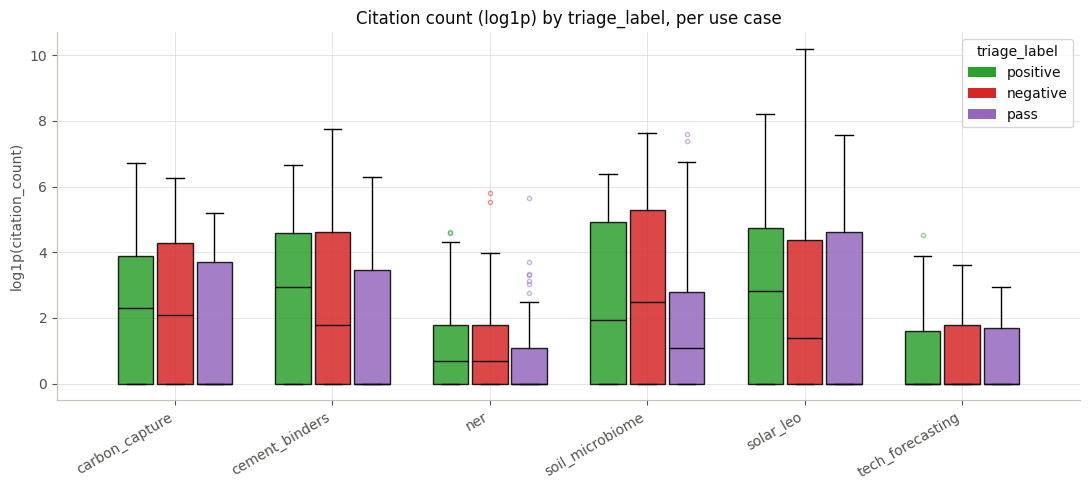

In [27]:
box_df = df.dropna(subset=["citation_count"]).copy()
box_df["log_citations"] = np.log1p(box_df["citation_count"])

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.25
x = np.arange(len(USE_CASE_ORDER))
for i, label in enumerate(LABEL_ORDER):
    data = [
        box_df.loc[(box_df["use_case_key"] == uc) & (box_df["triage_label"] == label), "log_citations"]
        for uc in USE_CASE_ORDER
    ]
    bp = ax.boxplot(
        data,
        positions=x + (i - 1) * width,
        widths=width * 0.9,
        patch_artist=True,
        medianprops={"color": "#0b0b0b"},
        flierprops={"markersize": 3, "markeredgecolor": LABEL_COLORS[label], "alpha": 0.5},
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(LABEL_COLORS[label])
        patch.set_alpha(0.85)

ax.set_xticks(x)
ax.set_xticklabels(USE_CASE_ORDER, rotation=30, ha="right")
ax.set_ylabel("log1p(citation_count)")
ax.set_title("Citation count (log1p) by triage_label, per use case")
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=LABEL_COLORS[l]) for l in LABEL_ORDER]
ax.legend(handles, LABEL_ORDER, title="triage_label", loc="upper right")
plt.tight_layout()
plt.show()